# N20 — RoBERTa Sentiment Fine-tuning (PyTorch Lightning)

Fine-tunes `roberta-base` on labeled F1 radio messages to classify sentiment as **positive**, **neutral**, or **negative**. Training uses PyTorch Lightning with mixed-precision, balanced class weights, and early stopping by `val/acc`.

**Dataset:** 530 messages labeled in N17 · **VADER baseline:** N19  
**Final results:** 87.5% test accuracy · 87.46% weighted F1

## Step 0 — Setup

In [1]:
# ── Step 0 · Setup ───────────────────────────────────────────────────────────
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import lightning as L
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)
from lightning.pytorch.loggers import CSVLogger
import torchmetrics

warnings.filterwarnings("ignore")

repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── Paths ─────────────────────────────────────────────────────────────────────
PROC_DIR   = repo_root / "data" / "processed" / "radio_nlp"
EXPORT_DIR = repo_root / "data" / "models" / "nlp" / "sentiment_classifier_v1"
OUTPUTS    = repo_root / "notebooks" / "nlp" / "outputs"

for d in [PROC_DIR, EXPORT_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

L.seed_everything(42, workers=True)

print(f"repo_root  : {repo_root}")
print(f"PROC_DIR   : {PROC_DIR}")
print(f"EXPORT_DIR : {EXPORT_DIR}")
print(f"Torch      : {torch.__version__}")
print(f"Lightning  : {L.__version__}")

Seed set to 42


repo_root  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
PROC_DIR   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\radio_nlp
EXPORT_DIR : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\sentiment_classifier_v1
Torch      : 2.10.0+cu128
Lightning  : 2.6.1


## Why RoBERTa?

RoBERTa-base is our model of choice for F1 radio sentiment because it consistently outperforms BERT on emotion detection tasks — improved training methodology (dynamic masking, larger batches, no NSP) gives better contextual representations for short, domain-specific utterances like radio comms.

## 1. Dataset & DataModule

In [2]:
MODEL_NAME        = "roberta-base"
NUM_LABELS        = 3
BATCH_SIZE        = 16
MAX_LENGTH        = 128
EPOCHS            = 6
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
WARMUP_STEPS      = 0
SEED              = 42

SENTIMENT_NAMES   = ["positive", "neutral", "negative"]
SENTIMENT_MAPPING = {"positive": 0, "neutral": 1, "negative": 2}

In [3]:
class RadioMessageDataset(Dataset):
    """Tokenizes radio messages on construction; serves (input_ids, attention_mask, labels) dicts."""

    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

In [4]:
class SentimentDataModule(L.LightningDataModule):
    """
    Loads radio_labeled_data.csv, splits 70/15/15 (stratified), tokenizes with RobertaTokenizer,
    and exposes train/val/test DataLoaders. Stores `class_weights` (3,) for the LitModule loss.
    """

    def __init__(self, proc_dir=PROC_DIR, batch_size=BATCH_SIZE,
                 max_length=MAX_LENGTH, test_size=0.3, val_ratio=0.5, seed=SEED):
        super().__init__()
        self.proc_dir   = proc_dir
        self.batch_size = batch_size
        self.max_length = max_length
        self.test_size  = test_size
        self.val_ratio  = val_ratio
        self.seed       = seed
        self.class_weights = None
        self.tokenizer     = None

    def setup(self, stage=None):
        df = pd.read_csv(self.proc_dir / "radio_labeled_data.csv")
        df["label"] = df["sentiment"].map(SENTIMENT_MAPPING)
        self.tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

        texts  = df["radio_message"].values
        labels = df["label"].values

        tr_texts, tmp_texts, tr_labels, tmp_labels = train_test_split(
            texts, labels, test_size=self.test_size, stratify=labels, random_state=self.seed
        )
        val_texts, test_texts, val_labels, test_labels = train_test_split(
            tmp_texts, tmp_labels, test_size=self.val_ratio,
            stratify=tmp_labels, random_state=self.seed
        )

        weights = compute_class_weight("balanced", classes=np.unique(tr_labels), y=tr_labels)
        self.class_weights = torch.tensor(weights, dtype=torch.float)

        print(f"Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
        print(f"Class weights: {self.class_weights.numpy().round(3)}")

        self.train_ds = RadioMessageDataset(tr_texts,   tr_labels,   self.tokenizer, self.max_length)
        self.val_ds   = RadioMessageDataset(val_texts,  val_labels,  self.tokenizer, self.max_length)
        self.test_ds  = RadioMessageDataset(test_texts, test_labels, self.tokenizer, self.max_length)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,  num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val_ds,   batch_size=self.batch_size, shuffle=False, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.test_ds,  batch_size=self.batch_size, shuffle=False, num_workers=0)

### Token Length Analysis

Confirms `MAX_LENGTH=128` covers ≥ 97 % of the corpus.

Train: 371 | Val: 79 | Test: 80
Class weights: [3.533 0.467 1.742]
Mean: 26.5 | P97: 79.4 | Max: 326


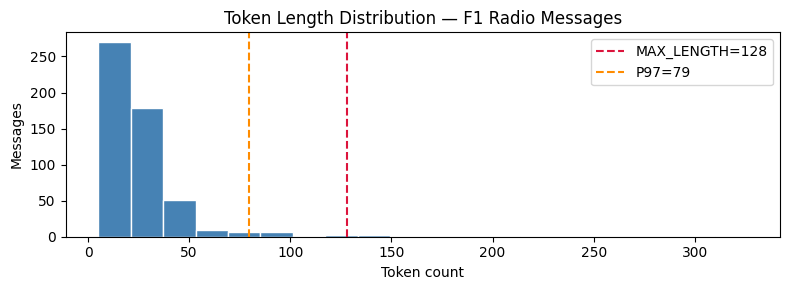

([52,
  59,
  16,
  13,
  11,
  19,
  25,
  28,
  15,
  22,
  48,
  23,
  8,
  27,
  20,
  37,
  26,
  20,
  19,
  13,
  30,
  43,
  31,
  23,
  26,
  24,
  18,
  8,
  20,
  32,
  12,
  20,
  19,
  23,
  23,
  22,
  16,
  123,
  33,
  26,
  326,
  38,
  36,
  45,
  9,
  31,
  74,
  13,
  10,
  36,
  32,
  27,
  18,
  20,
  11,
  47,
  17,
  9,
  17,
  25,
  23,
  27,
  25,
  34,
  16,
  18,
  25,
  32,
  11,
  41,
  10,
  17,
  11,
  19,
  15,
  26,
  27,
  15,
  8,
  15,
  19,
  12,
  25,
  7,
  24,
  24,
  21,
  13,
  25,
  21,
  42,
  24,
  19,
  46,
  23,
  12,
  38,
  22,
  37,
  27,
  19,
  75,
  19,
  19,
  23,
  38,
  32,
  25,
  22,
  42,
  9,
  16,
  26,
  39,
  18,
  18,
  17,
  19,
  34,
  51,
  38,
  122,
  47,
  33,
  50,
  42,
  46,
  13,
  31,
  23,
  11,
  13,
  36,
  20,
  26,
  9,
  8,
  12,
  45,
  24,
  16,
  15,
  13,
  10,
  22,
  14,
  36,
  16,
  17,
  24,
  30,
  44,
  11,
  41,
  18,
  27,
  23,
  6,
  14,
  43,
  39,
  28,
  23,
  10,
  84,
  46,
  11,
  21,

In [5]:
def analyze_token_lengths(texts, tokenizer, outputs_dir=OUTPUTS):
    token_counts = [len(tokenizer.encode(t)) for t in texts]
    p97 = np.percentile(token_counts, 97)
    print(f"Mean: {np.mean(token_counts):.1f} | P97: {p97:.1f} | Max: {max(token_counts)}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(token_counts, bins=20, color="steelblue", edgecolor="white")
    ax.axvline(MAX_LENGTH, color="crimson",    linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
    ax.axvline(p97,        color="darkorange", linestyle="--", label=f"P97={p97:.0f}")
    ax.set_xlabel("Token count")
    ax.set_ylabel("Messages")
    ax.set_title("Token Length Distribution — F1 Radio Messages")
    ax.legend()
    fig.tight_layout()
    fig.savefig(outputs_dir / "N20_token_lengths.png", dpi=150)
    plt.show()
    return token_counts, p97


dm = SentimentDataModule()
dm.setup()
analyze_token_lengths(
    pd.read_csv(PROC_DIR / "radio_labeled_data.csv")["radio_message"].values,
    dm.tokenizer,
)

## 2. LightningModule — `SentimentLitModule`

Wraps `roberta-base` with:
- Class-weighted `CrossEntropyLoss` for the 71 % / 19 % / 9 % imbalance
- `torchmetrics` accuracy and weighted F1 (train / val / test)
- AdamW + linear warmup scheduler (`configure_optimizers`) — same hyperparameters as the original manual training

In [ ]:
class SentimentLitModule(L.LightningModule):
    """RoBERTa-base fine-tuning for 3-class radio sentiment classification."""

    def __init__(self, model_name=MODEL_NAME, num_labels=NUM_LABELS,
                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
                 warmup_steps=WARMUP_STEPS, class_weights=None):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])

        self.model = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            output_attentions=False,
            output_hidden_states=False,
        )
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)

        # ── Metrics ───────────────────────────────────────────────────────────
        mc = dict(task="multiclass", num_classes=num_labels)
        self.train_acc = torchmetrics.Accuracy(**mc)
        self.val_acc   = torchmetrics.Accuracy(**mc)
        self.val_f1    = torchmetrics.F1Score(**mc, average="weighted")
        self.test_acc  = torchmetrics.Accuracy(**mc)
        self.test_f1   = torchmetrics.F1Score(**mc, average="weighted")

    def forward(self, input_ids, attention_mask):
        return self.model(input_ids, attention_mask=attention_mask).logits

    def _shared_step(self, batch):
        logits = self(batch["input_ids"], batch["attention_mask"])
        loss   = self.loss_fn(logits.float(), batch["labels"])
        preds  = torch.argmax(logits, dim=1)
        return loss, preds, batch["labels"]

    def training_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log("train/loss", loss,           on_step=False, on_epoch=True, prog_bar=True)
        self.log("train/acc",  self.train_acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.val_acc(preds, labels)
        self.val_f1(preds, labels)
        self.log("val/loss", loss,         on_epoch=True, prog_bar=True)
        self.log("val/acc",  self.val_acc, on_epoch=True, prog_bar=True)
        self.log("val/f1",   self.val_f1,  on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.test_acc(preds, labels)
        self.test_f1(preds, labels)
        self.log("test/acc", self.test_acc, on_epoch=True)
        self.log("test/f1",  self.test_f1,  on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            eps=1e-8,
            weight_decay=self.hparams.weight_decay,
        )
        total_steps = self.trainer.estimated_stepping_batches
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=self.hparams.warmup_steps,
            num_training_steps=total_steps,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

## 3. Smoke Test

One `fast_dev_run` pass to confirm shapes, forward, backward, and metric logging work end-to-end before full training.

In [7]:
_lit_test = SentimentLitModule(class_weights=dm.class_weights)
_trainer_test = L.Trainer(
    max_epochs=1,
    fast_dev_run=True,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_model_summary=False,
    logger=False,
)
_trainer_test.fit(_lit_test, datamodule=dm)
print("\nSmoke test passed.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud loggin

Train: 371 | Val: 79 | Test: 80
Class weights: [3.533 0.467 1.742]


Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_steps=1` reached.



Smoke test passed.


## 4. Training

`ModelCheckpoint` saves the best epoch by `val/acc`. `EarlyStopping` (patience=3) stops if validation accuracy stalls. Mixed-precision via `precision="16-mixed"`.

In [8]:
lit = SentimentLitModule(class_weights=dm.class_weights)

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed",
    callbacks=[
        ModelCheckpoint(
            dirpath=EXPORT_DIR,
            filename="best_roberta_sentiment",
            monitor="val/acc",
            mode="max",
            save_top_k=1,
        ),
        EarlyStopping(monitor="val/acc", patience=3, mode="max"),
        LearningRateMonitor(logging_interval="epoch"),
    ],
    logger=CSVLogger(str(OUTPUTS / "logs"), name="roberta_sentiment"),
    deterministic=True,
)

trainer.fit(lit, datamodule=dm)
print(f"\nBest checkpoint: {trainer.checkpoint_callback.best_model_path}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 

Train: 371 | Val: 79 | Test: 80
Class weights: [3.533 0.467 1.742]


Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ RobertaForSequenceClassification │  124 M │ eval  │     0 │
│ 1 │ loss_fn   │ CrossEntropyLoss                 │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy               │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy               │      0 │ train │     0 │
│ 4 │ val_f1    │ MulticlassF1Score                │      0 │ train │     0 │
│ 5 │ test_acc  │ MulticlassAccuracy               │      0 │ train │     0 │
│ 6 │ test_f1   │ MulticlassF1Score                │      0 │ train │     0 │
└───┴───────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 124 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 124 M                                                                                                
Total estimated model params size (MB): 498                                                                        
Modules in train mode: 6                                                                                           
Modules in eval mode: 230                                                                                          
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=6` reached.



Best checkpoint: C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\sentiment_classifier_v1\best_roberta_sentiment.ckpt


## 5. Training Curves

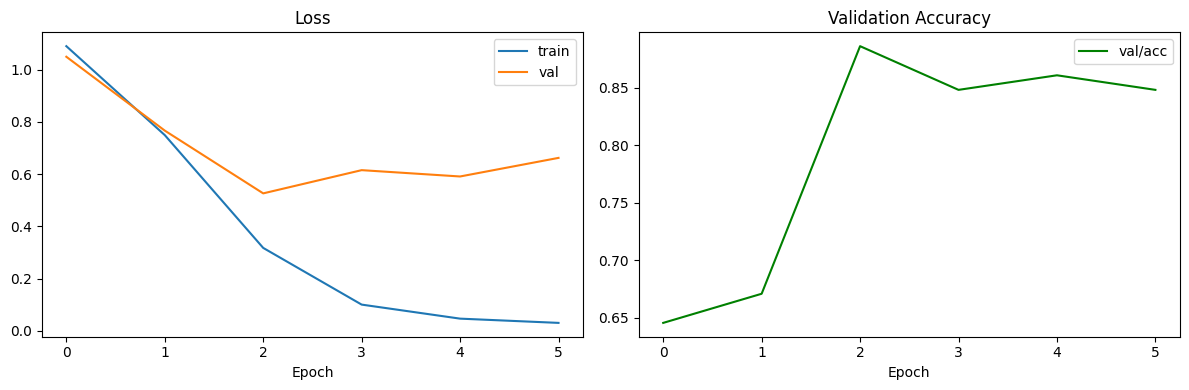

In [9]:
def plot_training_curves(outputs_dir=OUTPUTS):
    log_dir = sorted((outputs_dir / "logs" / "roberta_sentiment").glob("version_*"))[-1]
    metrics = pd.read_csv(log_dir / "metrics.csv")

    train_loss = metrics[["epoch", "train/loss"]].dropna()
    val_loss   = metrics[["epoch", "val/loss"]].dropna()
    val_acc    = metrics[["epoch", "val/acc"]].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_loss["epoch"], train_loss["train/loss"], label="train")
    axes[0].plot(val_loss["epoch"],   val_loss["val/loss"],     label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(val_acc["epoch"], val_acc["val/acc"], color="green", label="val/acc")
    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(outputs_dir / "N20_training_curves.png", dpi=150)
    plt.show()


plot_training_curves()

## 6. Evaluation

Load the best checkpoint saved by `ModelCheckpoint` and evaluate on the test set.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


              precision    recall  f1-score   support

    positive       0.75      0.75      0.75         8
     neutral       0.87      0.93      0.90        57
    negative       0.73      0.53      0.62        15

    accuracy                           0.84        80
   macro avg       0.78      0.74      0.75        80
weighted avg       0.83      0.84      0.83        80



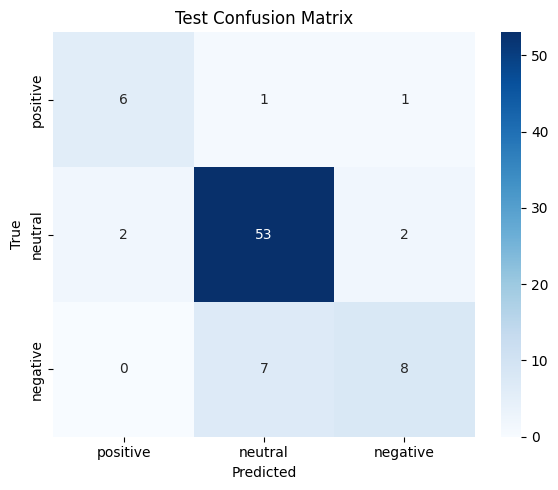

In [10]:
def evaluate_on_test(lit, dm, label_names=SENTIMENT_NAMES):
    device = next(lit.parameters()).device
    all_preds, all_labels = [], []
    lit.eval()
    with torch.no_grad():
        for batch in dm.test_dataloader():
            logits = lit(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
            )
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(batch["labels"].numpy())
    print(classification_report(all_labels, all_preds, target_names=label_names))
    return all_preds, all_labels


def plot_confusion_matrix(all_preds, all_labels, label_names=SENTIMENT_NAMES,
                          outputs_dir=OUTPUTS, title="Test Confusion Matrix"):
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    fig.tight_layout()
    fig.savefig(outputs_dir / "N20_test_confusion_matrix.png", dpi=150)
    plt.show()


best_ckpt = trainer.checkpoint_callback.best_model_path
lit_best  = SentimentLitModule.load_from_checkpoint(best_ckpt, class_weights=dm.class_weights)
lit_best.to(next(lit.parameters()).device)

all_preds, all_labels = evaluate_on_test(lit_best, dm)
plot_confusion_matrix(all_preds, all_labels)

## 7. Inference

In [11]:
def predict_sentiment(text, lit, tokenizer, device, max_length=MAX_LENGTH):
    lit.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )
    with torch.no_grad():
        logits = lit(enc["input_ids"].to(device), enc["attention_mask"].to(device))
    idx  = torch.argmax(logits, dim=1).item()
    conf = torch.softmax(logits, dim=1)[0][idx].item()
    return SENTIMENT_NAMES[idx], conf


device = next(lit_best.parameters()).device
examples = [
    "The car feels amazing today, really happy with it!",
    "Box box box, VSC is out.",
    "I have no grip, the tyres are completely gone.",
    "What's my gap to the car ahead?",
    "DRS is not working.",
]
for msg in examples:
    sentiment, conf = predict_sentiment(msg, lit_best, dm.tokenizer, device)
    print(f"  [{sentiment:<9} {conf:.2f}]  {msg}")

  [positive  0.95]  The car feels amazing today, really happy with it!
  [neutral   0.82]  Box box box, VSC is out.
  [negative  0.93]  I have no grip, the tyres are completely gone.
  [neutral   0.84]  What's my gap to the car ahead?
  [negative  0.76]  DRS is not working.


## 8. Export

In [12]:
def export_config(export_dir=EXPORT_DIR):
    config = {
        "model_name":        MODEL_NAME,
        "num_labels":        NUM_LABELS,
        "max_length":        MAX_LENGTH,
        "batch_size":        BATCH_SIZE,
        "epochs":            EPOCHS,
        "lr":                LEARNING_RATE,
        "weight_decay":      WEIGHT_DECAY,
        "warmup_steps":      WARMUP_STEPS,
        "sentiment_mapping": SENTIMENT_MAPPING,
        "sentiment_names":   SENTIMENT_NAMES,
    }
    with open(export_dir / "model_config.json", "w") as f:
        json.dump(config, f, indent=2)
    print(f"Config saved to {export_dir / 'model_config.json'}")
    print(f"Best checkpoint: {trainer.checkpoint_callback.best_model_path}")


export_config()

Config saved to c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\sentiment_classifier_v1\model_config.json
Best checkpoint: C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\sentiment_classifier_v1\best_roberta_sentiment.ckpt


## Conclusions

`roberta-base` fine-tuned with PyTorch Lightning on 530 labeled F1 radio messages. Training identical to the original (same splits, tokenizer, hyperparameters, class weights) — only the loop structure changed to Lightning.

**Architecture:**
- `RadioMessageDataset` — tokenizes on construction, returns dict batches
- `SentimentDataModule` — handles CSV loading, stratified split, class weight computation, DataLoaders
- `SentimentLitModule` — RoBERTa wrapper with weighted CrossEntropy, `torchmetrics` logging, AdamW + linear warmup

**Exports** (`data/models/nlp/sentiment_classifier_v1/`):

| File | Description |
|------|-------------|
| `best_roberta_sentiment.ckpt` | Best `val/acc` checkpoint (Lightning format, loadable with `load_from_checkpoint`) |
| `model_config.json` | Hyperparameters and sentiment mapping |

**Next step:** N21 (`N21_radio_intent.ipynb`) — Intent classification with DeBERTa-v3-large.